In [16]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.append(str(project_root / 'src'))

from env import *
from agents.train_dqn import train_dqn, DQNConfig
from agents.experiment import Experiment

In [17]:
df_train = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2022-2023.csv')
df_test = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2024.csv')

df_train.head()

,open,high,low,close,volume
0,46216.93,46731.39,46208.37,46656.13,1503.33095
1,46656.14,46949.99,46574.06,46778.14,943.81539
2,46778.14,46928.94,46721.96,46811.77,485.16860
3,46811.77,46916.63,46760.12,46813.20,562.88971
4,46813.21,46887.33,46591.23,46711.05,861.88389


In [18]:
# env_train = MyTradingEnv(df_train, max_steps=2000)
# env_train = SharpeReward(df_train, max_steps=2000)
# env_train = ReturnReward(df_train, max_steps=2000)
env_train = DrawdownAwareReward(df_train, max_steps=2000)


env_train.clear_history()
config = DQNConfig(total_timesteps=200_000)

exp = Experiment("dqn-drawdown")
result = train_dqn(env_train, config, exp)
result['model']

Using cuda device
Logging to /home/twisted/Code/DeepRLTradingResearch/experiments/dqn-drawdown/20260406-192800-02ad05
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2e+03    |
|    ep_rew_mean      | -163     |
|    exploration_rate | 0.81     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 381      |
|    time_elapsed     | 20       |
|    total_timesteps  | 8000     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.000157 |
|    n_updates        | 1749     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2e+03    |
|    ep_rew_mean      | -242     |
|    exploration_rate | 0.62     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 367      |
|    time_elapsed     | 43       |
|    total_timesteps  | 16000    |
| train

In [19]:
import seaborn as sns

sns.set_theme(style='whitegrid')

train_steps = env_train.get_steps_df()
train_steps.head()

,episode,step,df_index,action,reward,terminated,truncated,portfolio_value,cash,position,units,entry_price,position_value,holding_time,current_price,n_trades,last_exit_reason,unrealized_pnl
0,1,1,7280,0,0.000000,False,False,1000.000000,1000.0,0,0.000000,0.00,0.000000,0,20487.76,0,NaN,0.000000
1,1,2,7281,2,0.000000,False,False,1000.000000,2000.0,-1,0.048277,20714.01,-1000.000000,0,20714.01,0,NaN,0.000000
2,1,3,7282,1,-0.003529,False,False,998.235494,0.0,1,0.048106,20750.56,998.235494,0,20750.56,1,agent,0.000000
3,1,4,7283,1,-0.003692,False,False,997.272403,0.0,1,0.048106,20750.56,997.272403,1,20730.54,1,NaN,-0.963091
4,1,5,7284,1,-0.005837,False,False,995.720008,0.0,1,0.048106,20750.56,995.720008,2,20698.27,1,NaN,-2.515486


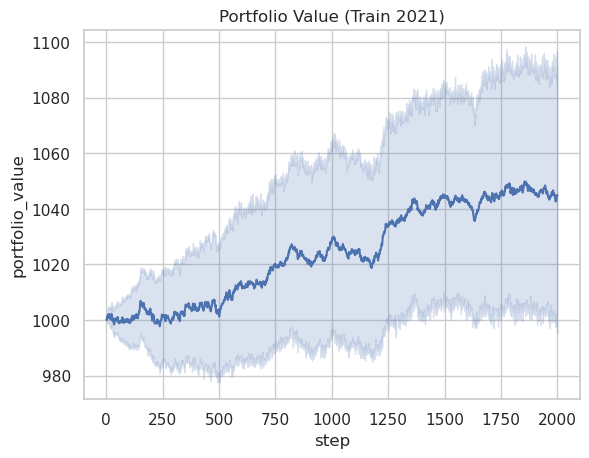

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

sns.lineplot(data=train_steps, x='step', y='portfolio_value')
plt.title('Portfolio Value (Train 2021)')
plt.show()
